In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *

In [2]:
# DATASET = "../datasets/AMLSim/1K user"

accounts = pd.read_csv('accounts.csv')
transactions = pd.read_csv('transactions.csv')

In [3]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [4]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]

    # if i == 0:
    #     print("first transaction must be from 6456 to 9069 => ", orig_acct, bene_acct)
    # if i == 1323233: # check that read till the last transaction
    #     print("\nlast transaction must be from 545 to 2724 => ", orig_acct, bene_acct)

    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount
        # elif tx_type == 'DEPOSIT':
        #    new_balance = last_balance + amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
        # if orig_acct == 1 and date == 1:
        #     print()
        #     print(row['TX_ID'])
        #     print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
        #     print(f"user {orig_acct} balance goes from {last_balance} to {new_balance}")
        #     print(balances[orig_acct])
            
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount
        # elif tx_type == 'WITHDRAWAL':
        #     new_balance = last_balance - amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})
        # if bene_acct == 0:
        #     print()
        #     print(row['TX_ID'])
        #     print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
        #     print(f"user {bene_acct} balance goes from {last_balance} to {new_balance}")
        #     print(balances[bene_acct])
            

In [5]:
len(balances)

1000

In [6]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}, {'date': 7, 'balance': 202.04}, {'date': 15, 'balance': 17.6}, {'date': 17, 'balance': 35.2}, {'date': 18, 'balance': 52.8}, {'date': 26, 'balance': 70.4}, {'date': 33, 'balance': -114.04}, {'date': 36, 'balance': -298.48}, {'date': 37, 'balance': -280.88}, {'date': 45, 'balance': -465.32}, {'date': 46, 'balance': -447.72}, {'date': 53, 'balance': -632.16}, {'date': 55, 'balance': -816.6}, {'date': 58, 'balance': -799.0}, {'date': 64, 'balance': -983.44}, {'date': 67, 'balance': -965.84}, {'date': 69, 'balance': -948.24}, {'date': 72, 'balance': -1132.68}, {'date': 76, 'balance': -1317.12}, {'date': 78, 'balance': -1299.52}, {'date': 86, 'balance': -1281.92}, {'date': 99, 'balance': -1264.32}, {'date': 105, 'balance': -1448.76}, {'date': 106, 'balance': -1431.16}, {'date': 108, 'balance': -1413.56}, {'date': 112, 'balance': -1598.0}, {'date': 116, 'balance': -1580.4}, {'date': 119, 'balance': -1562.8}, {'date': 125, 'balance': -1747.24}, {'date': 134,

In [7]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [8]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [9]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,0.01,151.13,140.49,178.38,240.20,147.66,158.34,...,1970.87,2003.49,2021.47,1035.51,228.15,505.04,232.48,433.74,733.72,414.21
1,184.44,175.80,142.06,-125.87,151.13,140.49,178.38,240.20,147.66,158.34,...,3906.09,4247.91,3456.31,2473.23,629.74,863.83,277.24,697.62,1380.83,520.12
2,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,6453.45,7247.03,5578.29,4370.97,261.70,883.60,304.16,1307.15,1805.36,866.03
3,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,9015.04,10664.13,6756.00,5978.22,974.83,921.38,131.35,1516.45,2628.90,1610.57
4,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,11674.79,14435.14,9031.86,7597.62,1856.49,1098.21,618.02,1903.67,3546.84,698.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2459.42,-425.25,-3324.70,...,11097918.04,12089534.68,14601036.72,34797516.99,9492793.06,10375104.27,13883185.18,21491333.73,14277318.48,19663746.89
196,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2329.10,-425.25,-3324.70,...,11100682.32,12092694.17,14603000.41,34798617.05,9493690.94,10375317.70,13883494.04,21491715.32,18981127.13,28210785.13
197,-2967.92,5052727.53,-2698.94,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11103791.12,12096145.37,25520923.82,34800442.38,9494511.40,10375612.51,15319097.36,21492112.69,25189362.25,32950725.75


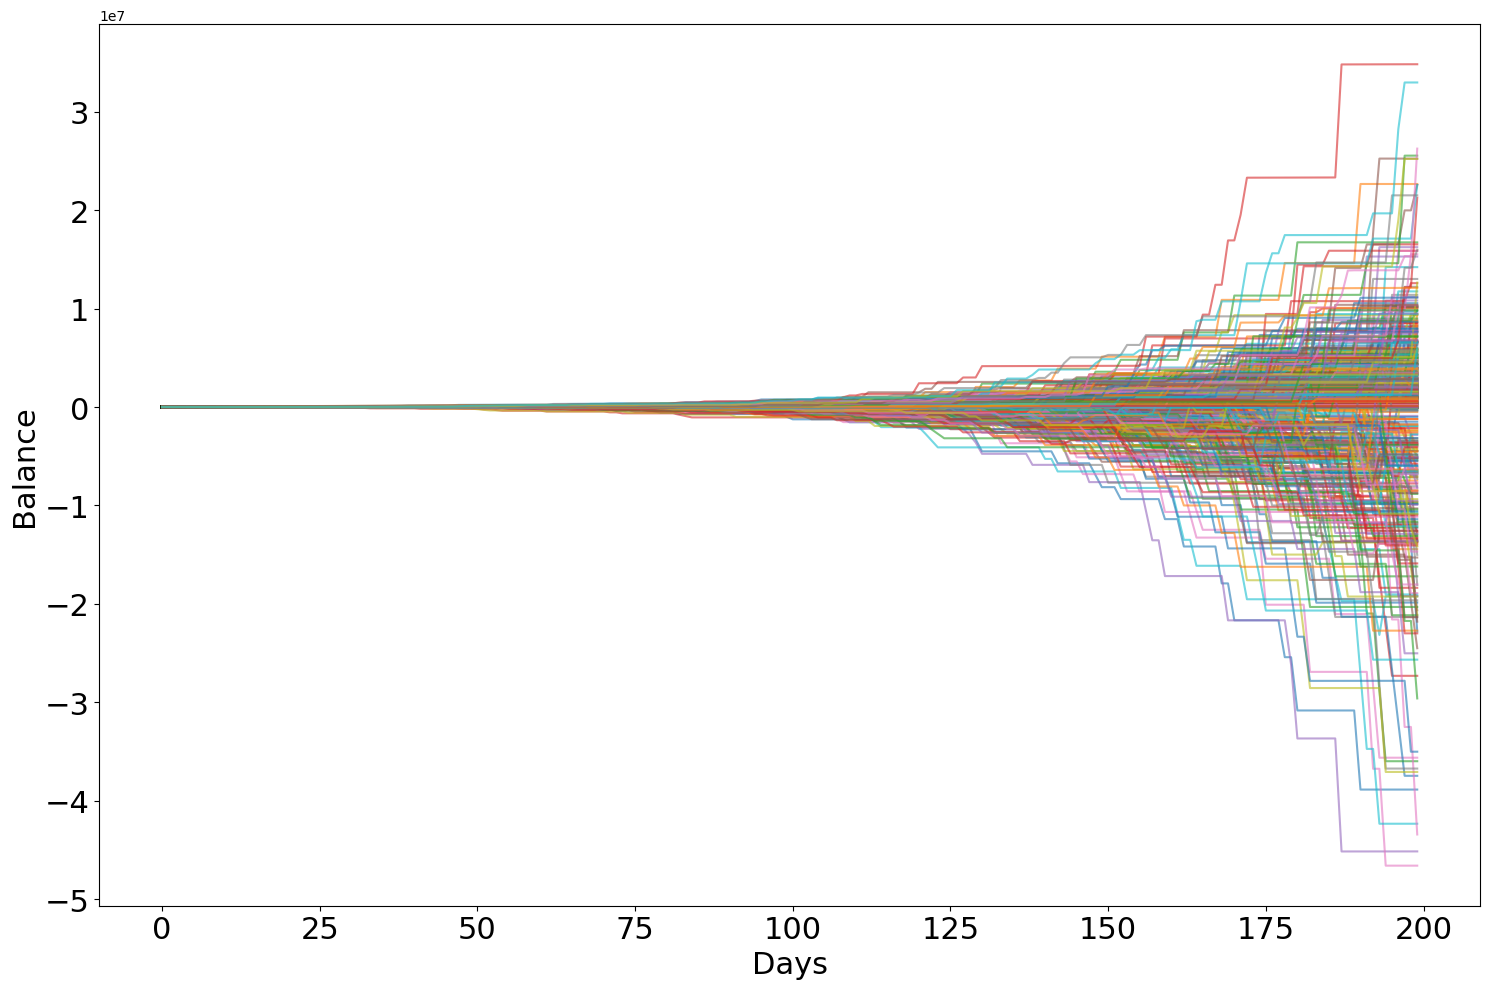

In [11]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

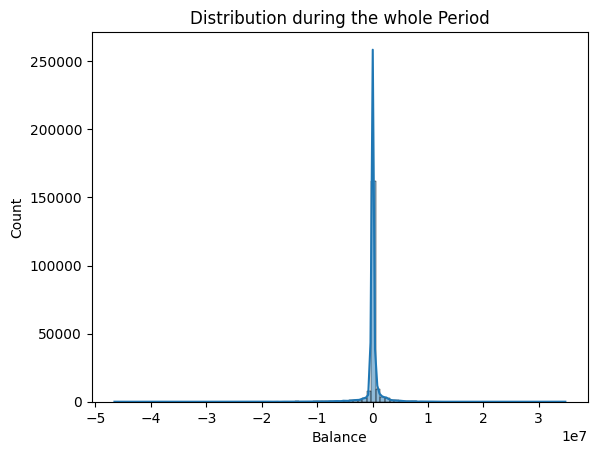

In [12]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

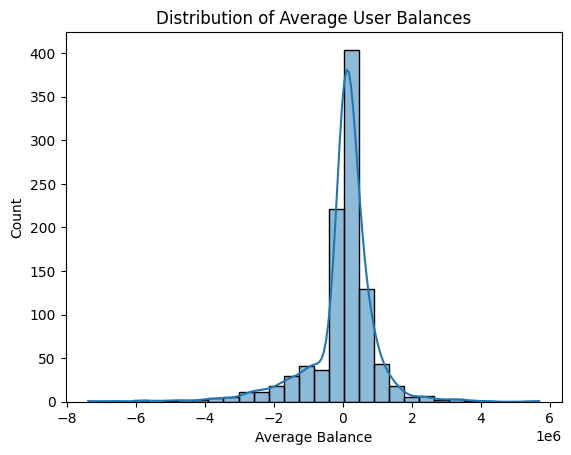

In [13]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [14]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,184.44,184.44,184.44,184.44,184.44,202.04,202.04,202.04,...,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92
1,175.80,175.80,175.80,175.80,175.80,175.80,175.80,175.80,0.00,0.00,...,241430.83,241430.83,241430.83,5052903.33,5052903.33,5052727.53,5052727.53,5052727.53,5052727.53,5052727.53
2,142.06,142.06,142.06,142.06,142.06,142.06,142.06,0.01,0.01,-142.04,...,-2556.89,-2556.89,-2556.89,-2556.89,-2556.89,-2556.89,-2556.89,-2698.94,-2840.99,-2840.99
3,0.01,-125.87,-251.75,-251.75,-251.75,-251.75,-251.75,-251.75,-251.75,-251.75,...,3005751.70,3005751.70,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82
4,151.13,151.13,151.13,151.13,151.13,151.13,151.13,0.01,0.01,0.01,...,-2720.15,-2720.15,-2720.15,-2720.15,-2720.15,-2720.15,-2720.15,-2871.27,-2871.27,-2871.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,505.04,863.83,883.60,921.38,1098.21,1139.64,1311.64,1919.17,2073.19,3817.23,...,10374460.88,10374829.70,10374866.98,10374927.44,10375104.27,10375104.27,10375317.70,10375612.51,10375776.06,10375785.59
996,232.48,277.24,304.16,131.35,618.02,686.25,948.89,1206.46,1213.77,1826.03,...,13882827.42,13882857.49,13882196.31,13882698.98,13883166.22,13883185.18,13883494.04,15319097.36,15319154.74,26236114.00
997,433.74,697.62,1307.15,1516.45,1903.67,2564.86,2934.70,1746.54,1792.12,1792.12,...,14679222.71,14679458.67,14680068.20,14678721.53,14679108.36,21491333.73,21491715.32,21492112.69,21492140.61,21492185.90
998,733.72,1380.83,1805.36,2628.90,3546.84,3989.42,4006.79,4216.60,4265.58,4590.76,...,14277174.59,14276268.66,14275176.64,14275987.01,14276892.80,14277318.48,18981127.13,25189362.25,25187826.64,25188141.01


In [15]:
ROWS = len(df.iloc[0])
ROWS

1000

## Squic DF

### Non normalized

In [16]:
# Y = df.T.to_numpy()  # Transpose to get shape (users, days)

In [17]:
# squic_dict = {}

In [18]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [19]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     X, computation_time = compute_squic(Y, rho)
#     computation_time = round(computation_time, 2)
#     squic_dict[rho] = X
#     print(f"time required: {computation_time} seconds")

#     nonz, nonz_r = count_nnz(squic_dict[rho], ROWS)

#     if is_symmetric(squic_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append('Yes')
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append('No')

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(computation_time)

#     if nonz == ROWS:
#         print(f"For rho = {rho} just element on the diagonal")
#         sparsity_pattern(squic_dict[rho])
#     elif nonz == ROWS * ROWS:
#         print(f"For rho = {rho} big dense matrix")
#         sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#     else:
#         print(f"For rho = {rho} there are some nnz")
#         sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
        

# table_squic = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

### Normalization

In [20]:
squic_norm_dict = {}

In [21]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [22]:
#l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]
# l = [95e-2, 9e-1, 85e-2, 8e-1, 75e-2, 7e-1, 65e-2, 6e-1, 55e-2, 5e-1]
# at 0.95 is very dense yet

l = [0.9999, 0.999, 0.998, 0.997, 0.995, 0.99]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.00e-03 nnz(S)/p=1.00e+00
* iter=1 time=2.49e-03 obj=6.19e+03 |delta(obj)|/obj=8.39e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=3.32e-03 obj=4.14e+03 |delta(obj)|/obj=4.97e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=4.01e-03 obj=3.45e+03 |delta(obj)|/o

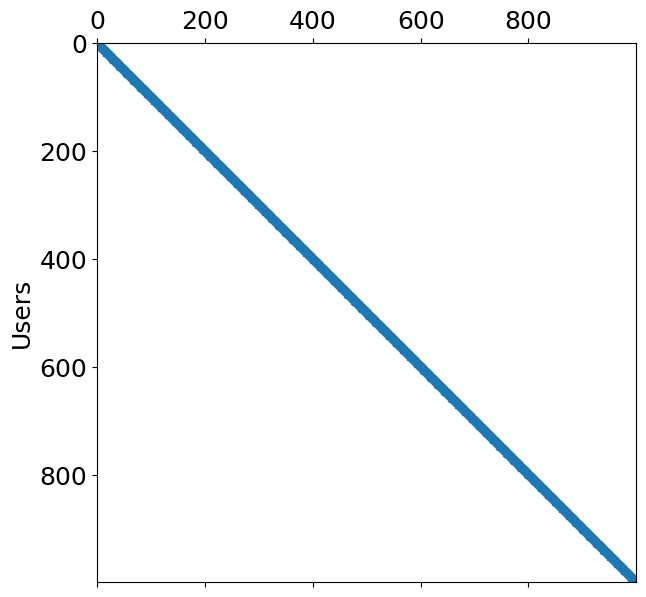

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e+00 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.25e-03 nnz(S)/p=1.00e+00
* iter=1 time=2.29e-03 obj=2.19e+03 |delta(obj)|/obj=5.44e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.95e-03 obj=2.14e+03 |delta(obj)|/obj=2.66e-02 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=3.67e-03 obj=2.10e+03 |delta(obj)|/o

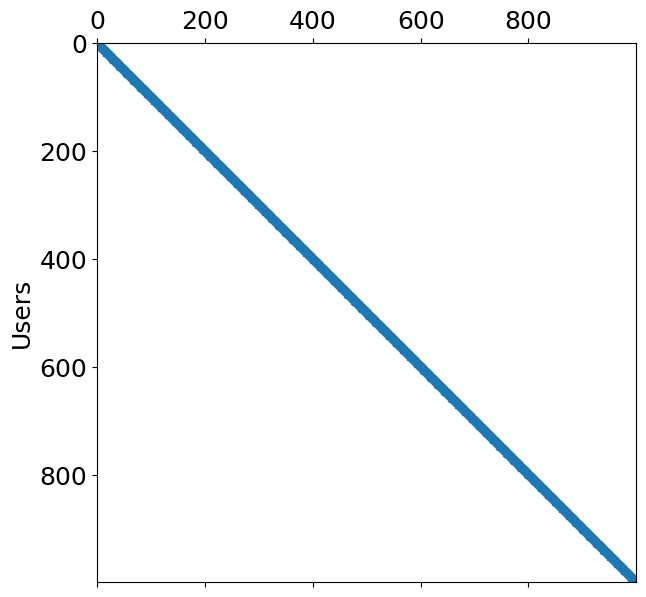

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.38e-03 nnz(S)/p=2.81e+00
* iter=1 time=2.31e-03 obj=1.69e+03 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[2.81e+00 1.52e+00 1.00e+00] lns_iter=2 
* iter=2 time=3.31e-03 obj=1.69e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[2.81e+00 1.52e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=8.37e-03 nnz(X,W)/p=[2.81e+0

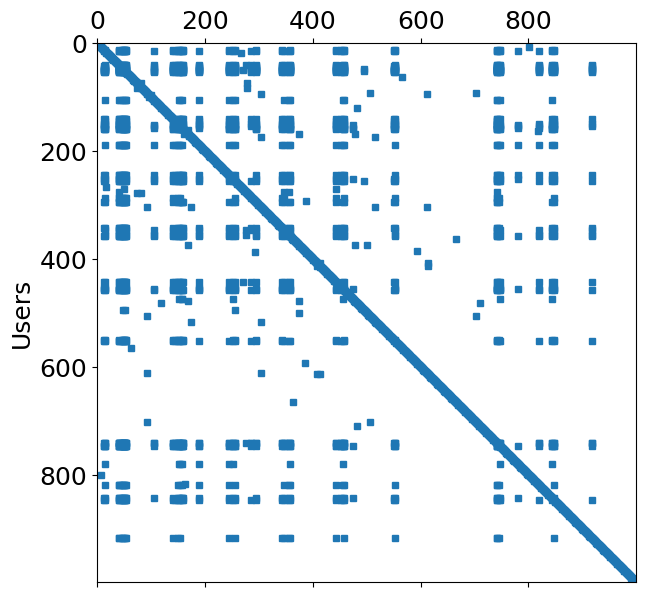

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.71e-03 nnz(S)/p=5.34e+00
* iter=1 time=2.99e-03 obj=1.69e+03 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[5.34e+00 2.77e+00 1.00e+00] lns_iter=2 
* iter=2 time=4.05e-03 obj=1.69e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[5.34e+00 2.77e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.02e-02 nnz(X,W)/p=[5.34e+0

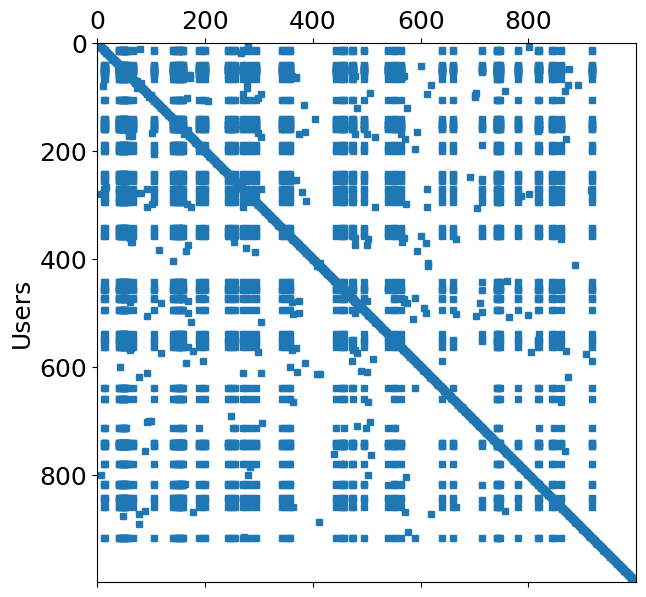

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.980000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.67e-03 nnz(S)/p=7.89e+00
* iter=1 time=2.95e-03 obj=1.69e+03 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[7.89e+00 4.50e+00 1.00e+00] lns_iter=2 
* iter=2 time=4.46e-03 obj=1.69e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[7.89e+00 4.50e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.05e-02 nnz(X,W)/p=[7.89e+0

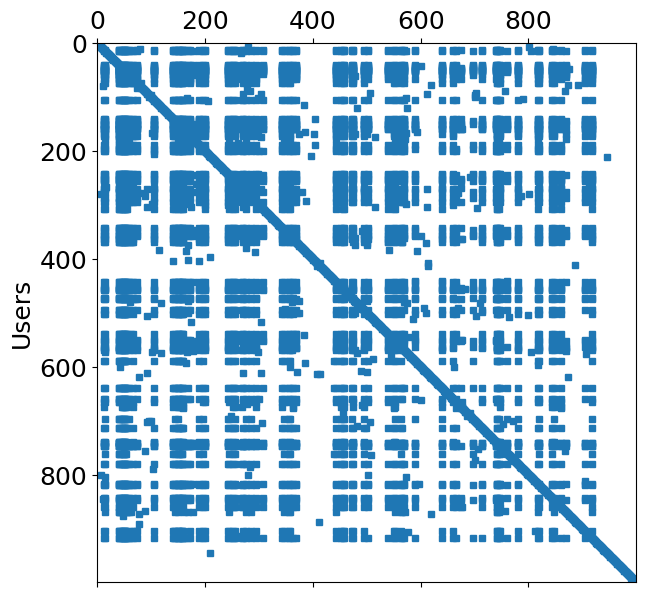

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.970000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.83e-03 nnz(S)/p=9.88e+00
* iter=1 time=3.24e-03 obj=1.69e+03 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[9.88e+00 5.51e+00 1.00e+00] lns_iter=2 
* iter=2 time=4.93e-03 obj=1.69e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[9.88e+00 5.51e+00 5.28e+00] lns_iter=1 
#SQUIC Finished: time=1.18e-02 nnz(X,W)/p=[9.88e+0

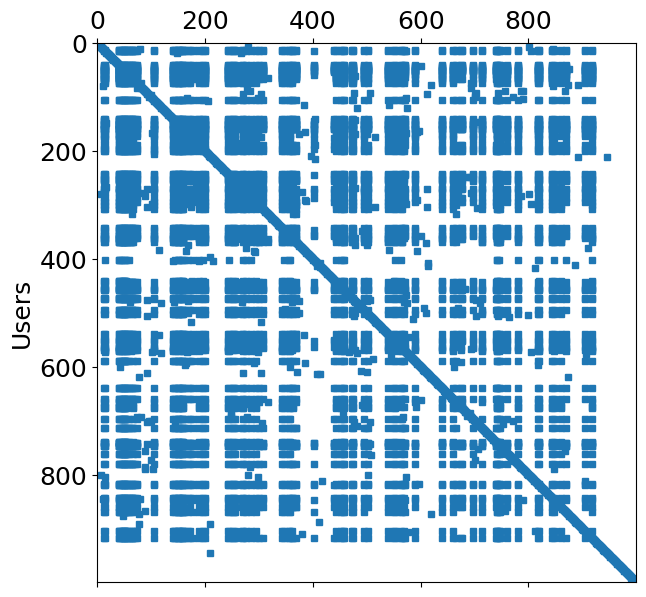

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.80e-03 nnz(S)/p=1.15e+01
* iter=1 time=3.76e-03 obj=1.69e+03 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[1.15e+01 6.15e+00 1.00e+00] lns_iter=2 
* iter=2 time=5.58e-03 obj=1.69e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[1.15e+01 6.15e+00 1.05e+01] lns_iter=1 
#SQUIC Finished: time=1.31e-02 nnz(X,W)/p=[1.15e+0

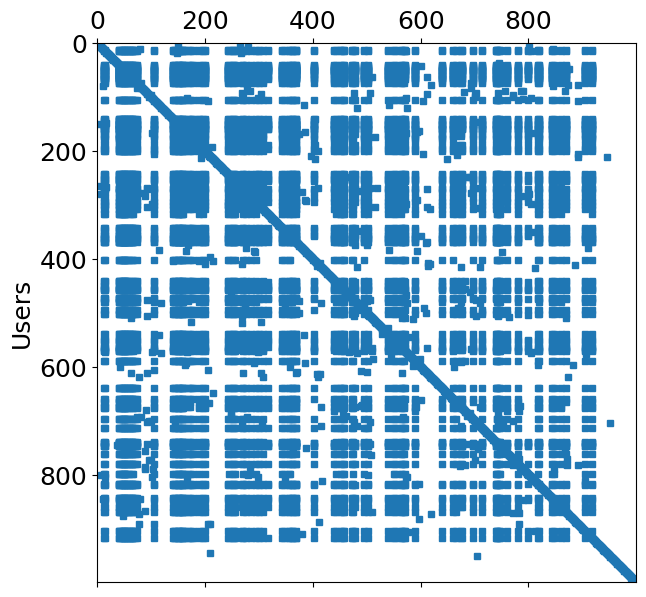

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.72e-03 nnz(S)/p=1.53e+01
* iter=1 time=4.48e-03 obj=1.69e+03 |delta(obj)|/obj=4.08e-01 nnz(X,L,W)/p=[1.53e+01 8.38e+00 1.00e+00] lns_iter=2 
* iter=2 time=8.10e-03 obj=1.69e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[1.53e+01 8.38e+00 1.57e+01] lns_iter=3 
#SQUIC Finished: time=1.64e-02 nnz(X,W)/p=[1.53e+0

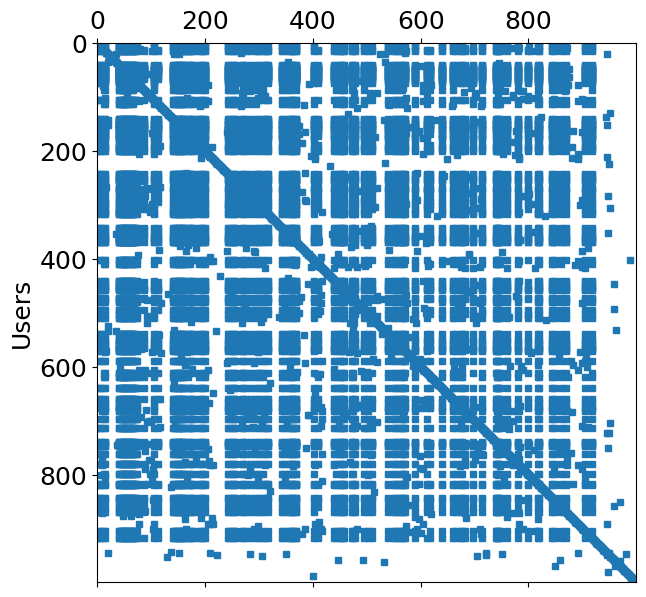

In [23]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_norm_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

## Squic-FIT

### Non normalized

In [30]:
# fit_dict = {}

In [31]:
# Y = df.T.to_numpy()  # Convert to (users, days)

In [32]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [ ]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     fit_dict[rho], end_time = squic_fit(Y, lambda_val=rho, eta=rho * 0.1)
#     end_time = round(end_time, 2)
#     print(f"required time: {end_time}")

#     nnz, nnz_r = nnz_fit(fit_dict[rho], ROWS)
#     print(f"nnz = {nnz} per rows = {nnz_r}")

#     if is_symmetric(fit_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append("Yes")
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append("No")

#     sparsity_pattern(fit_dict[rho])

#     data_nnz.append(nnz)
#     data_nnzr.append(nnz_r)
#     data_time.append(end_time)

# table_fit = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

### Normalization

In [24]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]
l = [0.9999, 0.999, 0.998, 0.997, 0.995, 0.99]

In [25]:
fit_norm_dict = {}

In [26]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [27]:
len(Y_new)

1000

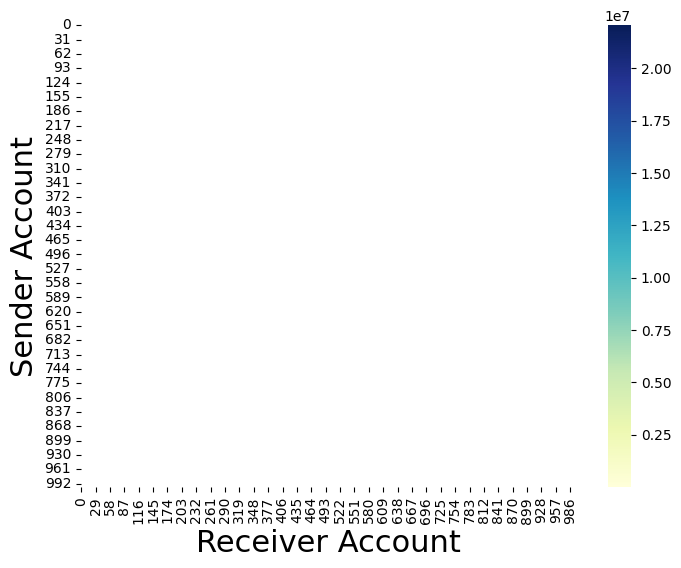

In [28]:
transactions = pd.read_csv('transactions.csv')
orig = "SENDER_ACCOUNT_ID"
dest = "RECEIVER_ACCOUNT_ID"
amnt = "TX_AMOUNT"

users_list = []
for _, row in transactions.iterrows():
    if row[orig] not in users_list:
        users_list.append(row[orig])
    if row[dest] not in users_list:
        users_list.append(row[dest])

id_to_int = {user_id: idx for idx, user_id in enumerate(users_list)} 


rows = len(Y_new)

matrix = np.zeros((rows, rows))

for _, row in transactions.iterrows():
    orig_acct = int(row[orig])
    bene_acct = int(row[dest])
    amount = float(row[amnt])

    matrix[orig_acct][bene_acct] += amount

mask = (matrix == 0) # cover all zeros

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, cmap='YlGnBu', fmt=".2f", cbar=True, mask=mask,
                linewidths=0.5, linecolor='white')

plt.xlabel("Receiver Account", fontsize=22)
plt.ylabel("Sender Account", fontsize=22)
plt.show()

Matrix shape: (1000, 1000)
Total elements: 1000000
Zero elements: 994109
Sparsity: 0.9941 (99.41% zeros)


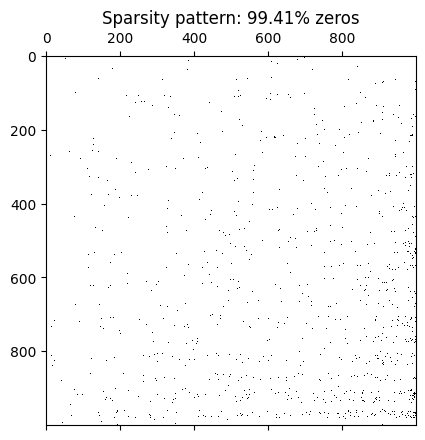

Matrix is sparse (>70.0% zeros). Converting to CSC format.
Memory usage before: 7812.50 KB
Memory usage after: 72.95 KB


In [29]:
from scipy import sparse

total_elements = matrix.size
zero_elements = np.count_nonzero(matrix == 0)
sparsity = zero_elements / total_elements

print(f"Matrix shape: {matrix.shape}")
print(f"Total elements: {total_elements}")
print(f"Zero elements: {zero_elements}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}% zeros)")

# Visualize the matrix (optional)
plt.spy(matrix)
plt.title(f"Sparsity pattern: {sparsity*100:.2f}% zeros")
plt.show()

sparsity_threshold = 0.7

# Convert to sparse if sparsity is above threshold
if sparsity > sparsity_threshold:
    print(f"Matrix is sparse (>{sparsity_threshold*100}% zeros). Converting to CSC format.")
    sparse_matrix = sparse.csc_matrix(matrix)
    print(f"Memory usage before: {matrix.nbytes / 1024:.2f} KB")
    print(f"Memory usage after: {sum(x.nbytes for x in [sparse_matrix.data, sparse_matrix.indices, sparse_matrix.indptr]) / 1024:.2f} KB")
    matrix = sparse_matrix
else:
    print(f"Matrix is not sparse enough (<{sparsity_threshold*100}% zeros). Keeping as dense.")


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=3.61e-03
* iter=1 time=2.47e-03 obj=8.28e+04 |delta(obj)|/obj=9.88e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=3.47e-03 obj=4.24e+04 |delta(obj)|/obj=9.51e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=4.59e-03 obj=2.26e+04 |d

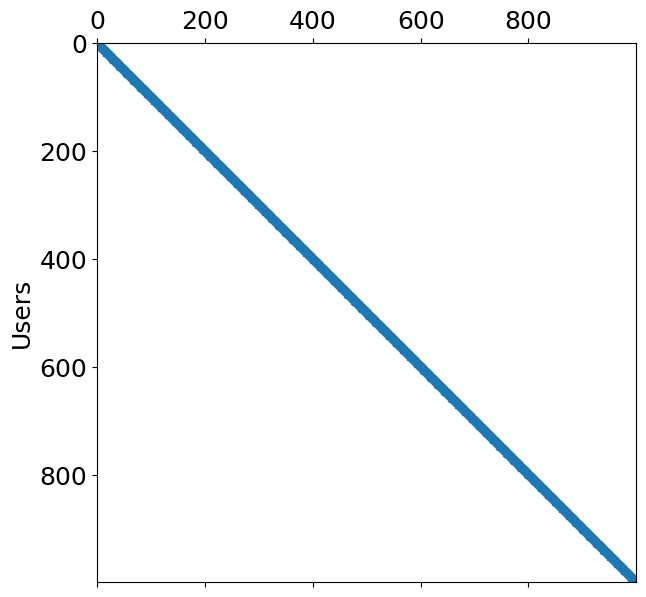

✅ Matrix is symmetric per rho 10

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e+00 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=2.58e-03
* iter=1 time=2.31e-03 obj=7.88e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=3.33e-03 obj=4.04e+04 |delta(obj)|/obj=9.50e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* ite

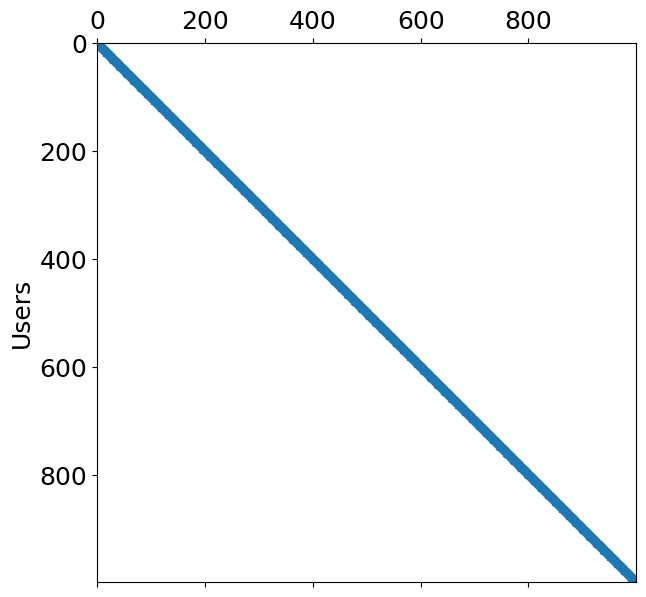

✅ Matrix is symmetric per rho 2

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.81e+00 time=2.62e-03
* iter=1 time=2.90e-03 obj=7.83e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[2.81e+00 1.52e+00 1.00e+00] lns_iter=2 
* iter=2 time=3.20e-03 obj=4.00e+04 |delta(obj)|/obj=9.58e-01 nnz(X,L,W)/p=[2.81e+00 1.52e+00 1.00e+00] lns_iter=2 
* iter

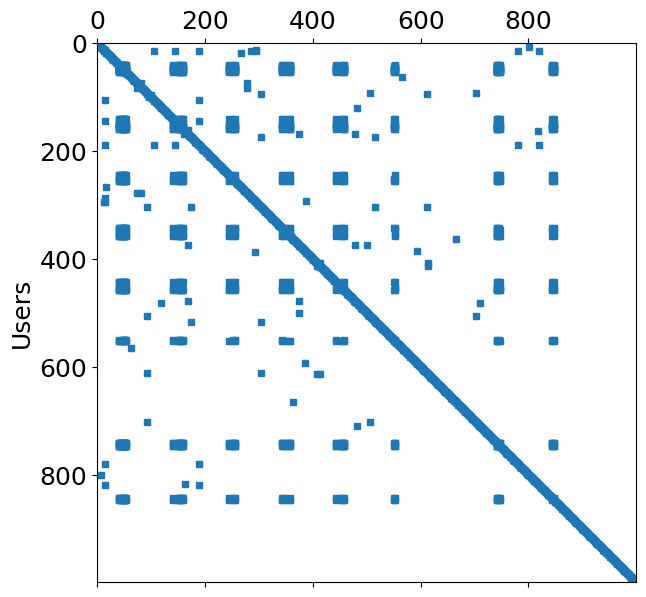

✅ Matrix is symmetric per rho 0.9999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=5.31e+00 time=2.35e-03
* iter=1 time=2.64e-03 obj=7.83e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[5.31e+00 2.77e+00 1.00e+00] lns_iter=2 
* iter=2 time=4.12e-03 obj=4.00e+04 |delta(obj)|/obj=9.58e-01 nnz(X,L,W)/p=[5.31e+00 2.77e+00 1.00e+00] lns_iter=2 
*

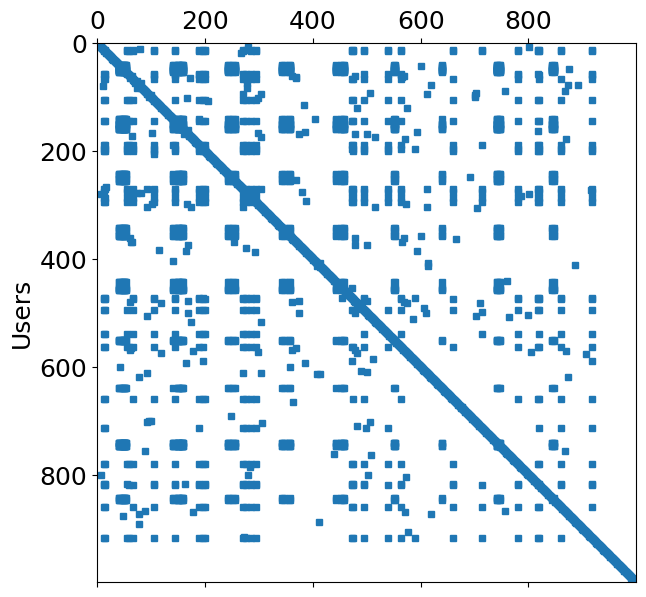

✅ Matrix is symmetric per rho 0.999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.980000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=7.84e+00 time=2.81e-03
* iter=1 time=3.26e-03 obj=7.83e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[7.84e+00 4.50e+00 1.00e+00] lns_iter=2 
* iter=2 time=4.96e-03 obj=4.00e+04 |delta(obj)|/obj=9.58e-01 nnz(X,L,W)/p=[7.84e+00 4.50e+00 1.00e+00] lns_iter=2 
* 

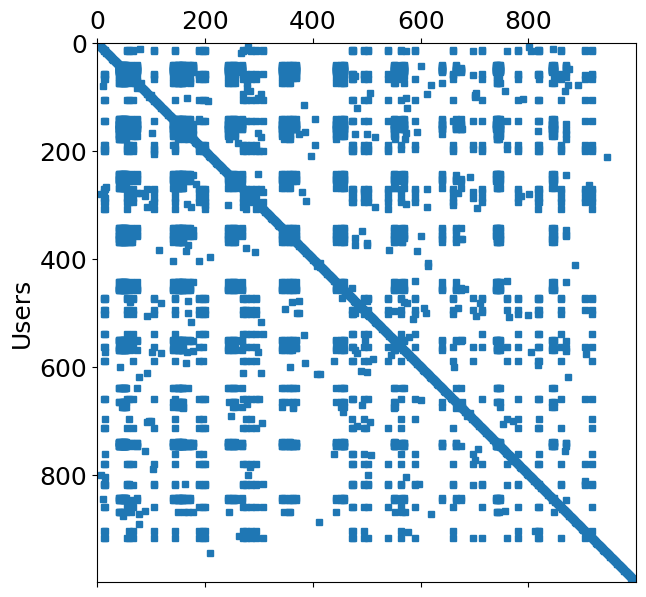

✅ Matrix is symmetric per rho 0.998

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.970000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=9.81e+00 time=2.86e-03
* iter=1 time=3.40e-03 obj=7.83e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[9.81e+00 5.50e+00 1.00e+00] lns_iter=2 
* iter=2 time=1.24e-02 obj=4.00e+04 |delta(obj)|/obj=9.58e-01 nnz(X,L,W)/p=[9.81e+00 5.50e+00 1.00e+00] lns_iter=2 
* 

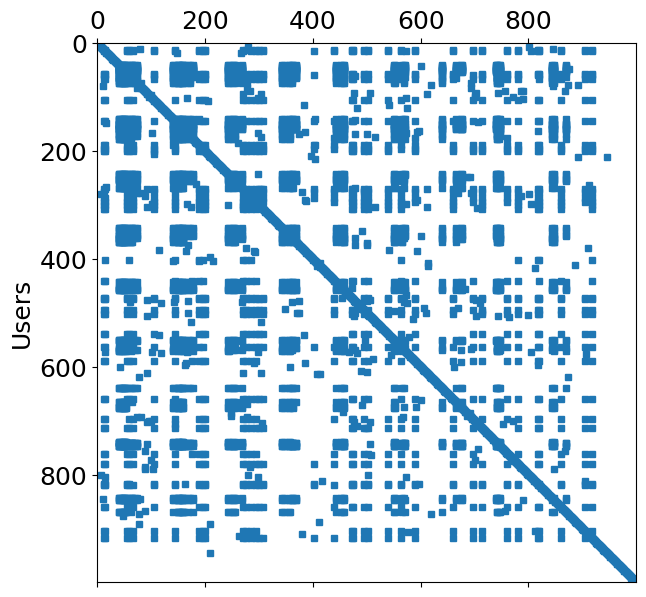

✅ Matrix is symmetric per rho 0.997

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.14e+01 time=2.71e-03
* iter=1 time=3.80e-03 obj=7.83e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[1.14e+01 6.15e+00 1.00e+00] lns_iter=2 
* iter=2 time=5.65e-03 obj=4.00e+04 |delta(obj)|/obj=9.58e-01 nnz(X,L,W)/p=[1.14e+01 6.15e+00 4.73e+00] lns_iter=2 
* 

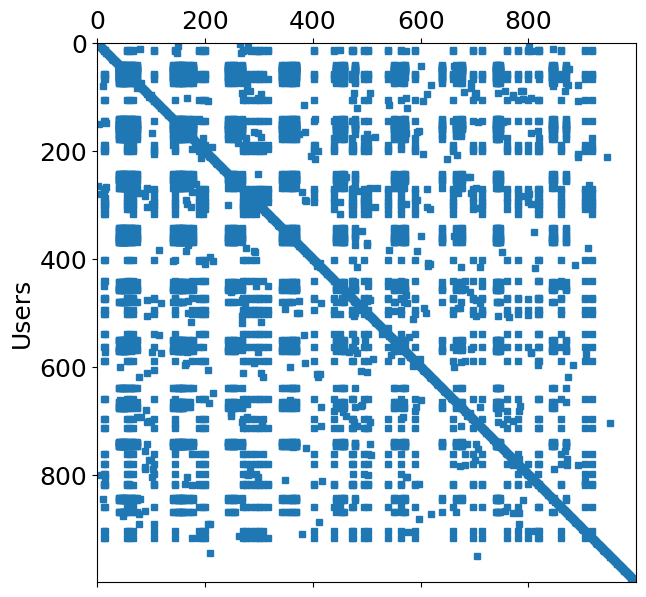

✅ Matrix is symmetric per rho 0.995

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.146400e+01
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.52e+01 time=3.15e-03
* iter=1 time=4.36e-03 obj=7.83e+04 |delta(obj)|/obj=9.87e-01 nnz(X,L,W)/p=[1.52e+01 8.31e+00 1.00e+00] lns_iter=2 
* iter=2 time=7.96e-03 obj=5.91e+04 |delta(obj)|/obj=3.24e-01 nnz(X,L,W)/p=[1.52e+01 8.31e+00 1.51e+01] lns_iter=3 
* 

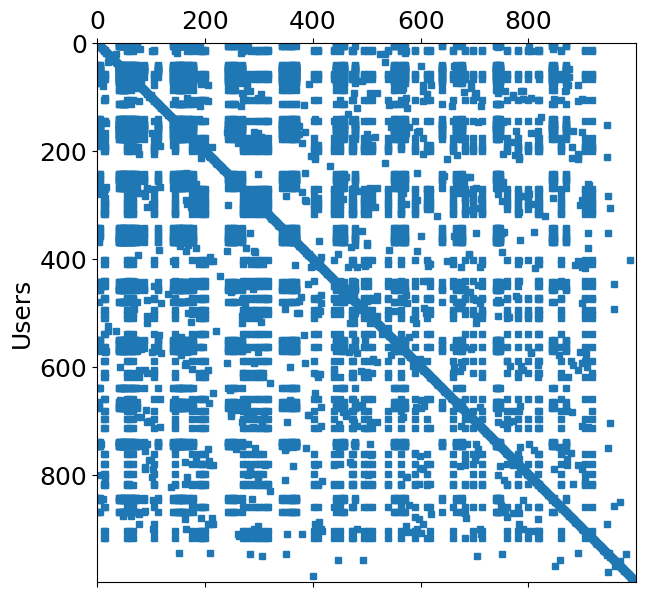

✅ Matrix is symmetric per rho 0.99


In [31]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit_matrix(Y_new, l=rho, matrix=matrix)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_norm_dict[rho])

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


# Table

In [32]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [34]:
#print(table(table_squic, "SQUIC", l))

print(table(table_squic_norm, "SQUIC NORM", l))

#print(table(table_fit, "SQUIC FIT", l)) 

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤══════╤══════╤══════════╤═════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC NORM  │  10  │  2   │  0.9999  │  0.999  │  0.998  │  0.997  │  0.995  │  0.99  │
╞══════════════╪══════╪══════╪══════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│     NNZ      │ 1000 │ 1000 │   2810   │  5338   │  7886   │  9880   │  11498  │ 15290  │
├──────────────┼──────┼──────┼──────────┼─────────┼─────────┼─────────┼─────────┼────────┤
│   NNZ/Row    │ 1.0  │ 1.0  │   2.81   │  5.34   │  7.89   │  9.88   │  11.5   │ 15.29  │
├──────────────┼──────┼──────┼──────────┼─────────┼─────────┼─────────┼─────────┼────────┤
│   Time (s)   │ 0.02 │ 0.02 │   0.01   │  0.01   │  0.01   │  0.01   │  0.01   │  0.02  │
├──────────────┼──────┼──────┼──────────┼─────────┼─────────┼─────────┼─────────┼────────┤
│  Symmetric   │ Yes  │ Yes  │   Yes    │   Yes   │   Yes   │   Yes   │   Yes   │  Yes   │
╘══════════════╧══════╧══════╧══════════╧═════════╧═════════╧═════════╧═════════╧════════╛